In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from benchmark.Promoterformer.data import BurstformerDataset
from benchmark.Promoterformer.net import  ChromoformerClassifier
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from benchmark.Promoterformer.constants import get_config


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False
eid = "E118"
fold = 0
# remove_marks = "H3K36me3"
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]


d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

if remove_marks:
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.remove_{remove_marks}.{fold}.bs_bf_para.model.pt"
else:
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.No_feature_bin.bs_bf_para.model.pt"
meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"


binsizes = [500]


#
# Setup end.
#

seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

# Split genes into two sets (train/val).
genes = set(meta.gene_id.unique())
n_genes = len(genes)
print("Target genes:", len(genes))
print(f"n_feats_p:{n_feats_p}")

splits = {
    1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
    2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
    3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
    4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
}

chromosome_splits = {}
for key, chroms in splits.items():
    for chrom in chroms:
        chromosome_splits[chrom] = key

qs = [
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
]

train_genes = (
    qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
)
val_genes = qs[(fold + 3) % 4]



print(len(train_genes), len(val_genes))

val_dataset = BurstformerDataset(
    meta_path,
    npy_dir,
    val_genes,
    i_max,
    binsizes,
    w_prom,
    w_max,
    config = config,
    with_gene_id=True
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

model = ChromoformerClassifier(
    n_feats_p,
    n_feats_pcres,
    d_emb,
    d_head,
    feature_bin_kws=feature_bin_kws,
    embed_kws=embed_kws,
    binsizes=binsizes,
    seed=42,
    targets=targets,
    add_feature_bin = add_feature_bin,
).to(DEVICE)

ckpt = torch.load(checkpoints,map_location=DEVICE)
model.load_state_dict(ckpt["net"])
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}



/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target genes: 13958
n_feats_p:7
10579 3379


In [2]:
def evaluation(out:'torch.Tensor', label:torch.Tensor):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return label, pred, acc, auc, ap

In [3]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


### BS pred score marks strength

In [5]:
from src.data.utils import bin_and_padding
eid='E118'
data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions.csv')

df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')

high_gene_ids = list(df[df['bs_label_label']==1][['gene_id','strand']].values)
high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)
with open(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_highmarks.npy", 'wb') as f:
    np.save(f,high_marks)

low_gene_ids = list(df[df['bs_label_label']==0][['gene_id','strand']].values)
low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)
with open(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_lowmarks.npy", 'wb') as f:
    np.save(f,low_marks)


### BF pred score marks strength

In [6]:
from src.data.utils import bin_and_padding
eid='E118'
data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_predictions.csv')

df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')

high_gene_ids = list(df[df['bf_label_label']==1][['gene_id','strand']].values)
high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
high_marks = np.mean(high_marks, axis=0)
with open(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_highmarks.npy", 'wb') as f:
    np.save(f,high_marks)

low_gene_ids = list(df[df['bf_label_label']==0][['gene_id','strand']].values)
low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
low_marks = np.mean(low_marks, axis=0)
with open(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_lowmarks.npy", 'wb') as f:
    np.save(f,low_marks)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


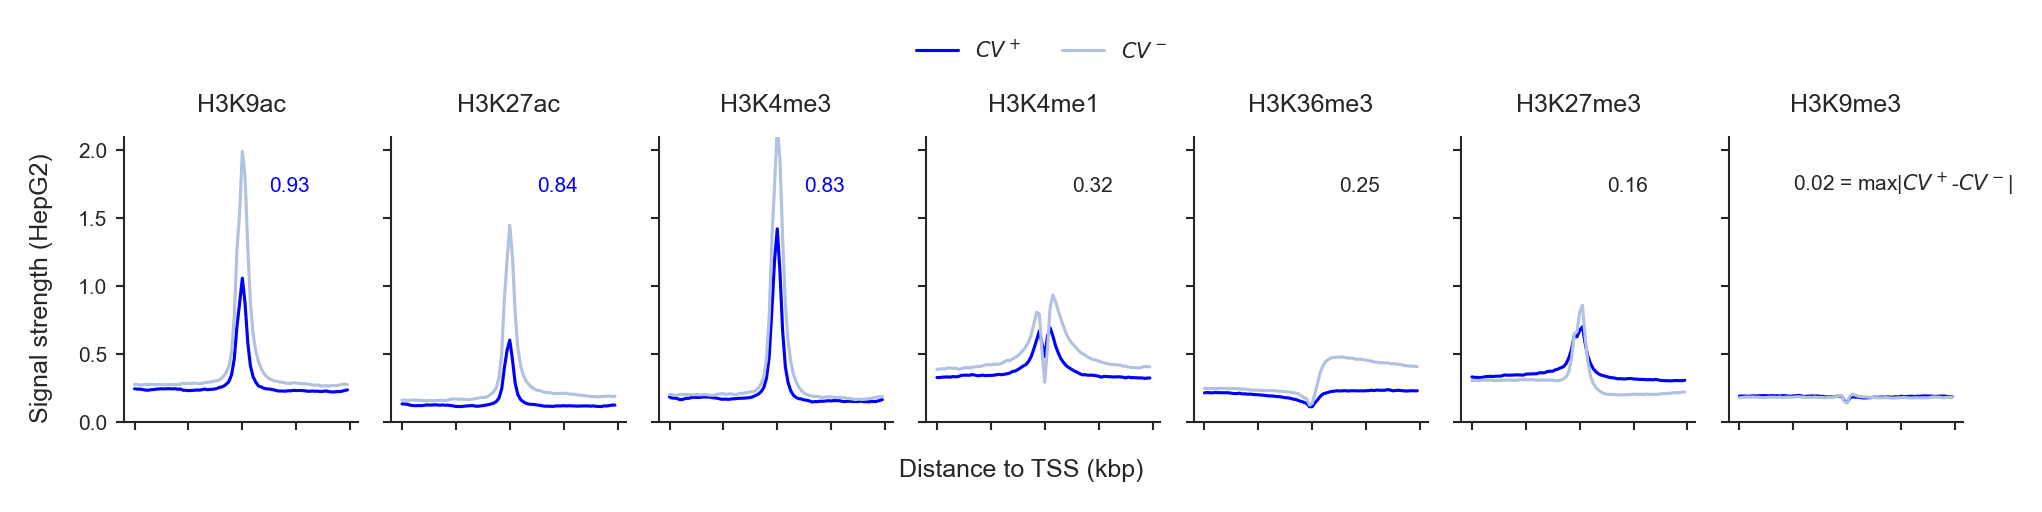

In [ ]:
eid = 'E118'
high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='blue',  ax=ax[idx % 7])
    sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[idx % 7])
    # ax[idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
    if idx < 3:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
    elif idx ==6:
        ax[idx % 7].text(20,1.7,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$BS^+$-$BS^-$|",fontdict={"size":5})
    else:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[idx % 7].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[idx % 7].set_title(mark, fontsize=6,fontweight='regular')
    ax[idx % 7].set_ylim(ymax=2.1)
    # Set the xlabel for each subplot

lines = ax[6].get_lines()

handles = [lines[0], lines[1]]
labels = ["$BS^+$", "$BS^-$"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.51, 1.15) , title_fontsize=6,fontsize=5,ncol=4,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
fig.align_ylabels()
# Adjust layout to ensure everything fits



plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


In [4]:
with open('extra/datasets/benchmark/Promoterformer/results/bs_bf_indicators.csv','w') as w:
    line = ['eid','target','indicator','value','fold']
    w.write(','.join(line) + '\n')
    for _eid in ["E003","E118","E116"]:
        data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{_eid}_predictions_bs_bf.csv')

        for _fold in [0,1,2,3]:
            _data = data[data['fold']==_fold]
            for target in targets:
                label = _data[f'{target}_label']
                pred = _data[f'{target}_pred']
                score = _data[f'{target}_score']
                acc = metrics.accuracy_score(label, pred) * 100
                auc = metrics.roc_auc_score(label, score) * 100
                ap = metrics.average_precision_score(label, score) * 100
                line = [_eid,target,'AUC',str(auc),str(fold)]          
                w.write(','.join(line) + '\n')
                line = [_eid,target,'ACC',str(acc),str(fold)]          
                w.write(','.join(line) + '\n')
                line = [_eid,target,'AP',str(ap),str(fold)]          
                w.write(','.join(line) + '\n')




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_70526/3638584870.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)


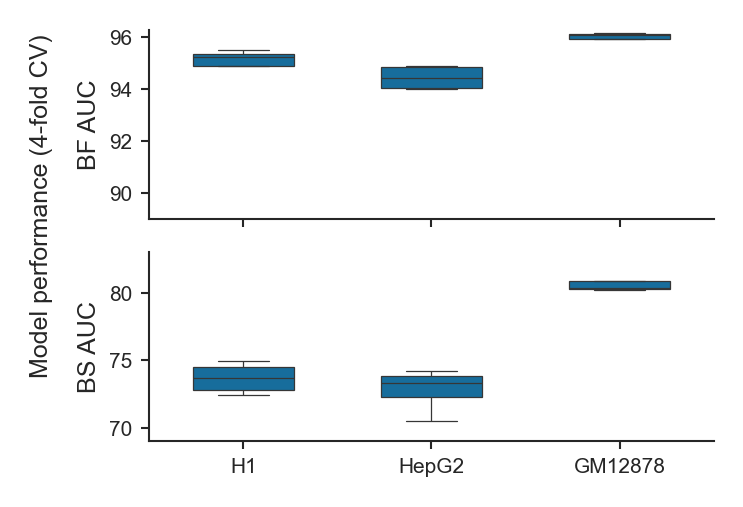

In [4]:
from matplotlib.ticker import FuncFormatter

indicators = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_indicators.csv')

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')


# 自定义格式化函数
def format_func(value, tick_number):
    return f"{value:.0f}"



sns.boxplot(data=indicators[(indicators['indicator']=='AUC') & (indicators['target']=='bf_label')],x='eid',y='value',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax[0],order=order,
                #  hue_order=hue_order,
                 gap=0.1,width=0.6)

# Show the plot
ax[0].set_ylabel("BF AUC",fontsize=6)
ax[0].set_xlabel("")
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_ylim(ymin=89)
# handles, labels = ax.get_legend_handles_labels()
# labels = ["BF","BS"]
ax[0].legend().remove()

ax[0].set_xticklabels("")
ax[0].yaxis.set_major_formatter(FuncFormatter(format_func))



sns.boxplot(data=indicators[(indicators['indicator']=='AUC') & (indicators['target']=='bs_label')],x='eid',y='value',
                 fliersize=0, 
                 linewidth=0.3,
                 ax=ax[1],order=order,
                #  hue_order=hue_order,
                 gap=0.1,width=0.6,)

# Show the plot
ax[1].set_ylabel("BS AUC",fontsize=6)
ax[1].set_xlabel("")
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_ylim(ymin=69)
# handles, labels = ax.get_legend_handles_labels()s
# labels = ["BF","BS"]
ax[1].legend().remove()

ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)
ax[1].yaxis.set_major_formatter(FuncFormatter(format_func))

fig.supylabel('Model performance (4-fold CV)',fontsize=6,y=0.6)

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=5,ncol=1,edgecolor='none')
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure2B.eps', format='eps', bbox_inches='tight')

# plt.tight_layout()  # Adjust layout to ensure nothing is cut off
plt.show()

In [11]:
indicators

,eid,target,indicator,value,fold
0,E003,bs_label,AUC,72.713661,0
1,E003,bs_label,ACC,65.463196,0
2,E003,bs_label,AP,66.367189,0
3,E003,bs_label,AUC,71.797869,0
4,E003,bs_label,ACC,66.624748,0
5,E003,bs_label,AP,68.700310,0
6,E003,bs_label,AUC,74.681874,0
7,E003,bs_label,ACC,69.014477,0
8,E003,bs_label,AP,68.630731,0
9,E003,bs_label,AUC,70.929715,0
